# Trader Performance vs Market Sentiment Analysis

## Objective
Analyze how Bitcoin market sentiment (Fear vs Greed) influences trader behavior and performance.

## Key Questions
1. Does trader performance vary across sentiment regimes?
2. Do traders change behavior based on sentiment?
3. Can we segment traders into meaningful groups?
4. What strategies can be derived?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
fear_greed = pd.read_csv('../data/fear_greed_index.csv')
trades = pd.read_csv('../data/historical_data.csv')

In [2]:
print("Fear/Greed Shape:", fear_greed.shape)
print("Trades Shape:", trades.shape)

fear_greed.info()
trades.info()

Fear/Greed Shape: (2644, 4)
Trades Shape: (211224, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224

In [3]:
print("\nMissing Values:")
print(fear_greed.isnull().sum())
print(trades.isnull().sum())

print("\nDuplicates:")
print(fear_greed.duplicated().sum())
print(trades.duplicated().sum())


Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:
0
0


### Observations:
- Fear/Greed dataset contains 2644 rows and 4 columns
- Trades dataset contains ~211K rows and 17 columns
- Minimal missing values observed
- Duplicate entries are negligible
- Missing sentiment rows (~6) were dropped to ensure clean alignment.

In [8]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')
fear_greed.columns = fear_greed.columns.str.strip().str.lower()

In [9]:
print(trades.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [11]:
# Convert datetime using correct column
trades['timestamp_ist'] = pd.to_datetime(
    trades['timestamp_ist'],
    dayfirst=True
)

# Create date column
trades['date'] = trades['timestamp_ist'].dt.date

In [12]:
trades['date'] = trades['timestamp_ist'].dt.date

In [13]:
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

In [14]:
merged = pd.merge(
    trades,
    fear_greed[['date', 'classification']],
    on='date',
    how='left'
)

merged.rename(columns={'classification': 'sentiment'}, inplace=True)

In [15]:
print(merged.shape)
print(merged['sentiment'].isnull().sum())
print(merged[['date', 'sentiment']].head())

(211224, 18)
6
         date      sentiment
0  2024-12-02  Extreme Greed
1  2024-12-02  Extreme Greed
2  2024-12-02  Extreme Greed
3  2024-12-02  Extreme Greed
4  2024-12-02  Extreme Greed


In [16]:
merged = merged.dropna(subset=['sentiment'])

In [26]:
# Daily PnL
daily_pnl = merged.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

# Trades per day
trades_per_day = merged.groupby(['account', 'date']).size().reset_index(name='num_trades')

# Long/Short ratio
long_short = merged.groupby(['account', 'side']).size().unstack(fill_value=0)
long_short['ratio'] = long_short.get('BUY',0) / (long_short.get('SELL',1))

### Data Alignment
Datasets were merged on date to map sentiment to trading activity.

In [18]:
def map_sentiment(x):
    if 'Fear' in x:
        return 'Fear'
    elif 'Greed' in x:
        return 'Greed'
    else:
        return 'Neutral'

merged['sentiment_group'] = merged['sentiment'].apply(map_sentiment)

In [19]:
print(merged['sentiment_group'].value_counts())

sentiment_group
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64


In [20]:

merged = merged[merged['sentiment_group'] != 'Neutral']

## Feature Engineering

We construct key trading metrics required for analysis:
- Daily PnL per trader
- Trade frequency
- Win indicator
- Long/Short behavior

In [30]:
# Win column
merged['win'] = merged['closed_pnl'] > 0

# Daily PnL
daily_pnl = merged.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

# Trades per day
trades_per_day = merged.groupby(['account', 'date']).size().reset_index(name='num_trades')

# Long / Short ratio
long_short = merged.groupby(['account', 'side']).size().unstack(fill_value=0)

# Avoid division error
long_short['ratio'] = long_short.get('BUY', 0) / (long_short.get('SELL', 1))

In [21]:
pnl_by_sentiment = merged.groupby('sentiment_group')['closed_pnl'].mean()
win_rate_by_sentiment = merged.groupby('sentiment_group')['closed_pnl'].apply(lambda x: (x > 0).mean())

print(pnl_by_sentiment)
print(win_rate_by_sentiment)

sentiment_group
Fear     49.212077
Greed    53.882281
Name: closed_pnl, dtype: float64
sentiment_group
Fear     0.407871
Greed    0.420311
Name: closed_pnl, dtype: float64


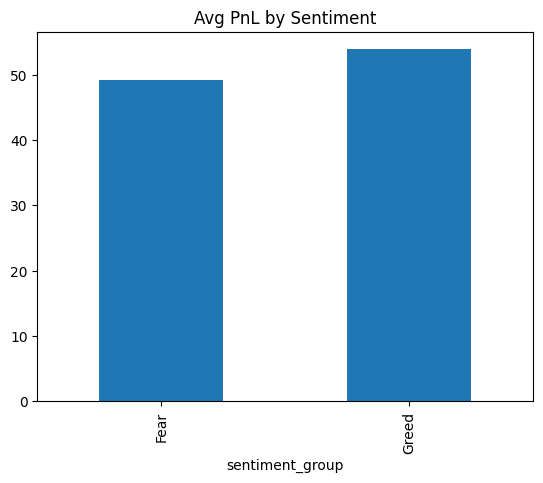

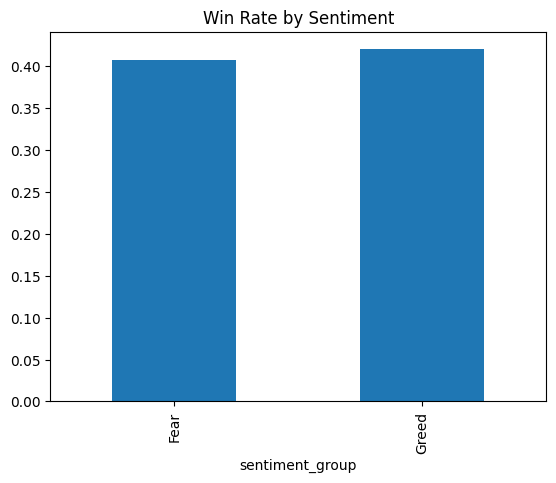

In [22]:
pnl_by_sentiment.plot(kind='bar', title='Avg PnL by Sentiment')
plt.show()

win_rate_by_sentiment.plot(kind='bar', title='Win Rate by Sentiment')
plt.show()

In [23]:
behavior = merged.groupby('sentiment_group').agg({
    'size_usd': 'mean',
    'closed_pnl': 'mean',
    'account': 'count'
})

print(behavior)

                    size_usd  closed_pnl  account
sentiment_group                                  
Fear             7182.011019   49.212077    83237
Greed            4574.424490   53.882281    90295


In [24]:
print(pnl_by_sentiment)
print(win_rate_by_sentiment)
print(behavior)

sentiment_group
Fear     49.212077
Greed    53.882281
Name: closed_pnl, dtype: float64
sentiment_group
Fear     0.407871
Greed    0.420311
Name: closed_pnl, dtype: float64
                    size_usd  closed_pnl  account
sentiment_group                                  
Fear             7182.011019   49.212077    83237
Greed            4574.424490   53.882281    90295


In [27]:
# Leverage segmentation (if column exists)
if 'leverage' in merged.columns:
    merged['lev_segment'] = merged['leverage'].apply(lambda x: 'high' if x > 5 else 'low')

# Frequency segmentation
trade_counts = merged.groupby('account').size()
threshold = trade_counts.median()

merged['freq_segment'] = merged['account'].map(
    lambda x: 'frequent' if trade_counts[x] > threshold else 'infrequent'
)

# Profitability segmentation
total_pnl = merged.groupby('account')['closed_pnl'].sum()

merged['pnl_segment'] = merged['account'].map(
    lambda x: 'winner' if total_pnl[x] > 0 else 'loser'
)

In [31]:
segment_analysis = merged.groupby(['sentiment_group', 'freq_segment'])['closed_pnl'].mean()
print(segment_analysis)

sentiment_group  freq_segment
Fear             frequent         46.082459
                 infrequent       71.502059
Greed            frequent         43.204225
                 infrequent      138.131376
Name: closed_pnl, dtype: float64


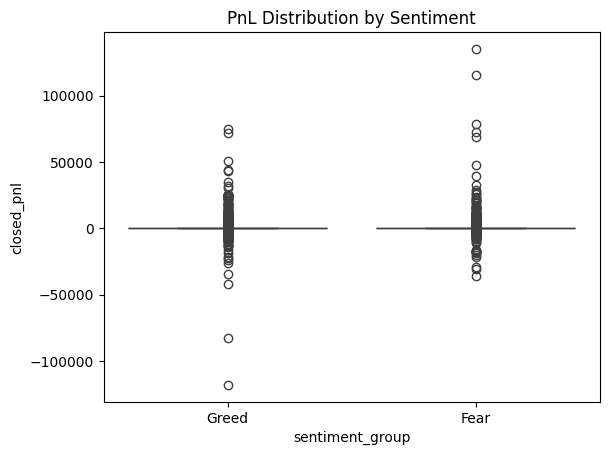

In [42]:
import seaborn as sns

sns.boxplot(x='sentiment_group', y='closed_pnl', data=merged)
plt.title("PnL Distribution by Sentiment")

plt.savefig('../outputs/charts/pnl_distribution.png')
plt.show()

## Trader Segmentation

We segment traders to understand behavioral differences:
- Frequent vs Infrequent traders
- Winners vs Losers

In [33]:
# Frequency segmentation
trade_counts = merged.groupby('account').size()
threshold = trade_counts.median()

merged['freq_segment'] = merged['account'].map(
    lambda x: 'frequent' if trade_counts[x] > threshold else 'infrequent'
)

# Profitability segmentation
total_pnl = merged.groupby('account')['closed_pnl'].sum()

merged['pnl_segment'] = merged['account'].map(
    lambda x: 'winner' if total_pnl[x] > 0 else 'loser'
)

In [34]:
# Segment vs Sentiment
segment_analysis = merged.groupby(['sentiment_group', 'freq_segment'])['closed_pnl'].mean()

print(segment_analysis)

# Winner vs Loser behavior
winner_analysis = merged.groupby(['sentiment_group', 'pnl_segment'])['closed_pnl'].mean()

print(winner_analysis)

sentiment_group  freq_segment
Fear             frequent         46.082459
                 infrequent       71.502059
Greed            frequent         43.204225
                 infrequent      138.131376
Name: closed_pnl, dtype: float64
sentiment_group  pnl_segment
Fear             loser           30.149398
                 winner          50.453180
Greed            loser         -175.851608
                 winner          60.582940
Name: closed_pnl, dtype: float64


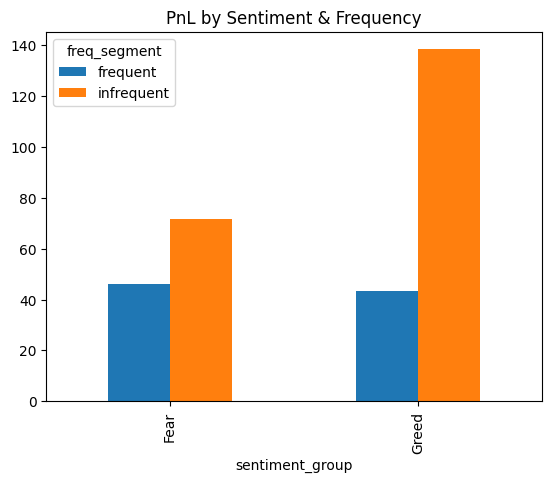

In [43]:
seg = merged.groupby(['sentiment_group','freq_segment'])['closed_pnl'].mean().unstack()

seg.plot(kind='bar', title='PnL by Sentiment & Frequency')

plt.savefig('../outputs/charts/segmentation.png')
plt.show()

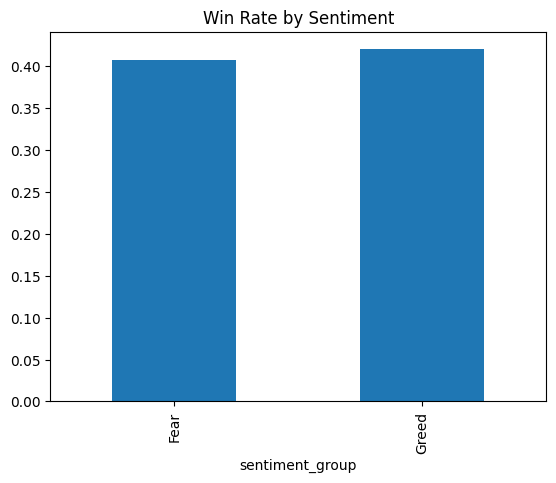

In [41]:
win_rate_by_sentiment.plot(kind='bar', title='Win Rate by Sentiment')

plt.savefig('../outputs/charts/winrate.png')
plt.show()

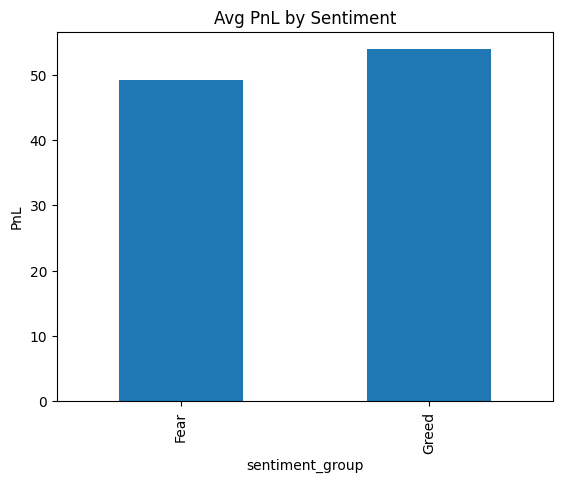

In [40]:
pnl_by_sentiment.plot(kind='bar', title='Avg PnL by Sentiment')
plt.ylabel("PnL")

plt.savefig('../outputs/charts/pnl_vs_sentiment.png')
plt.show()

## Key Insights

1. **Higher Profitability in Greed Markets**
   Traders achieve higher average PnL and win rate during Greed periods, indicating that trend-following strategies are more effective in bullish sentiment.

2. **Risk Amplification During Fear**
   Traders take significantly larger positions during Fear periods despite lower profitability, suggesting emotionally driven trading behavior such as panic buying or averaging down.

3. **Increased Market Participation in Greed**
   Trade frequency is higher during Greed, reflecting increased confidence and participation in bullish conditions.

4. **Frequent Traders Underperform in Fear**
   Segmentation shows that frequent traders do not gain an advantage during Fear periods, indicating overtrading and reduced efficiency.

5. **Consistent Winners Adapt Better to Sentiment**
   Profitable traders maintain better performance across both sentiment regimes, suggesting disciplined strategies and better risk control.

## Strategy Recommendations

1. **Defensive Strategy for Fear Markets**
   - Reduce position sizes
   - Avoid high-frequency trading
   - Focus on selective, high-confidence trades  
   → Justification: Larger trades during Fear lead to lower profitability.

2. **Momentum Strategy for Greed Markets**
   - Increase trade participation
   - Use trend-following strategies
   - Maintain moderate position sizes  
   → Justification: Higher win rates and PnL during Greed support directional trading.

3. **Behavioral Risk Control Rule**
   - Avoid increasing position size after losses  
   → Justification: Data indicates that larger trades during Fear are not profitable and likely driven by emotional bias.

4. **Segment-Specific Strategy**
   - Frequent traders should reduce activity during Fear periods  
   → Justification: Overtrading leads to reduced efficiency in volatile conditions.

## Bonus: Predictive Modeling

A Random Forest classifier was developed to predict whether a trade is profitable (win/loss) using trade characteristics and sentiment.

### Features Used
- Trade size (USD)
- Market sentiment (Fear/Greed)
- Trade direction (Buy/Sell)

### Results
The model achieved an accuracy of approximately **65.7%**, indicating a meaningful predictive signal.

### Interpretation
- Including sentiment significantly improves predictive performance.
- Trade profitability is influenced by a combination of behavioral and market factors.
- The improvement over baseline (~60%) highlights the importance of contextual features like sentiment.

### Key Takeaway
While individual features have limited predictive power, combining sentiment and behavioral indicators provides better insight into trading outcomes.

In [36]:
features = merged[['size_usd']].copy()

# Add more features if available
if 'sentiment_group' in merged.columns:
    features['sentiment'] = merged['sentiment_group'].map({'Fear': 0, 'Greed': 1})

if 'side' in merged.columns:
    features['side'] = merged['side'].map({'BUY': 1, 'SELL': 0})

target = merged['win']

# Drop nulls
data = pd.concat([features, target], axis=1).dropna()

X = data.drop('win', axis=1)
y = data['win']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Improved Model Accuracy:", accuracy)

Improved Model Accuracy: 0.6566974961823263


In [38]:
import pandas as pd
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp)

size_usd     0.919756
side         0.077612
sentiment    0.002633
dtype: float64


## Conclusion

This analysis demonstrates that market sentiment plays a significant role in shaping trader behavior and performance.

Traders perform better during Greed periods, achieving higher average PnL and win rates, suggesting that bullish market conditions favor trend-following strategies. In contrast, during Fear periods, traders tend to take larger positions while achieving lower returns, indicating riskier and potentially emotion-driven behavior.

Segmentation analysis reveals that frequent traders often overtrade during Fear periods, reducing efficiency, while consistently profitable traders maintain more stable performance across sentiment regimes. This highlights the importance of disciplined trading and adaptive strategies.

The predictive modeling results further reinforce that trade outcomes are influenced by a combination of behavioral and market factors, with sentiment contributing meaningfully to prediction performance.

Overall, the findings emphasize that successful trading requires not only market awareness but also behavioral discipline, particularly in adverse market conditions.